Ground truth image not found: /hpc/group/youlab/ks723/storage/Exp_images/Final_Test_set_preprocess_v3/86_1.TIF
Ground truth image not found: /hpc/group/youlab/ks723/storage/Exp_images/Final_Test_set_preprocess_v3/86_2.TIF
Ground truth image not found: /hpc/group/youlab/ks723/storage/Exp_images/EmrahPaKp_dataset_renamed/Test_set_preprocess_noaug/86_1.TIF
Ground truth image not found: /hpc/group/youlab/ks723/storage/Exp_images/EmrahPaKp_dataset_renamed/Test_set_preprocess_noaug/86_2.TIF
Ground truth image not found: /hpc/group/youlab/ks723/storage/Exp_images/Final_Test_set_preprocess_v3/126_1.TIF
Ground truth image not found: /hpc/group/youlab/ks723/storage/Exp_images/Final_Test_set_preprocess_v3/126_2.TIF
Ground truth image not found: /hpc/group/youlab/ks723/storage/Exp_images/NL_evolution_library_Image/additional_strain_from_KuiZhu_PlosBiology_plustestset_preprocess_noaug/126_1.TIF
Ground truth image not found: /hpc/group/youlab/ks723/storage/Exp_images/NL_evolution_library_Image/addit

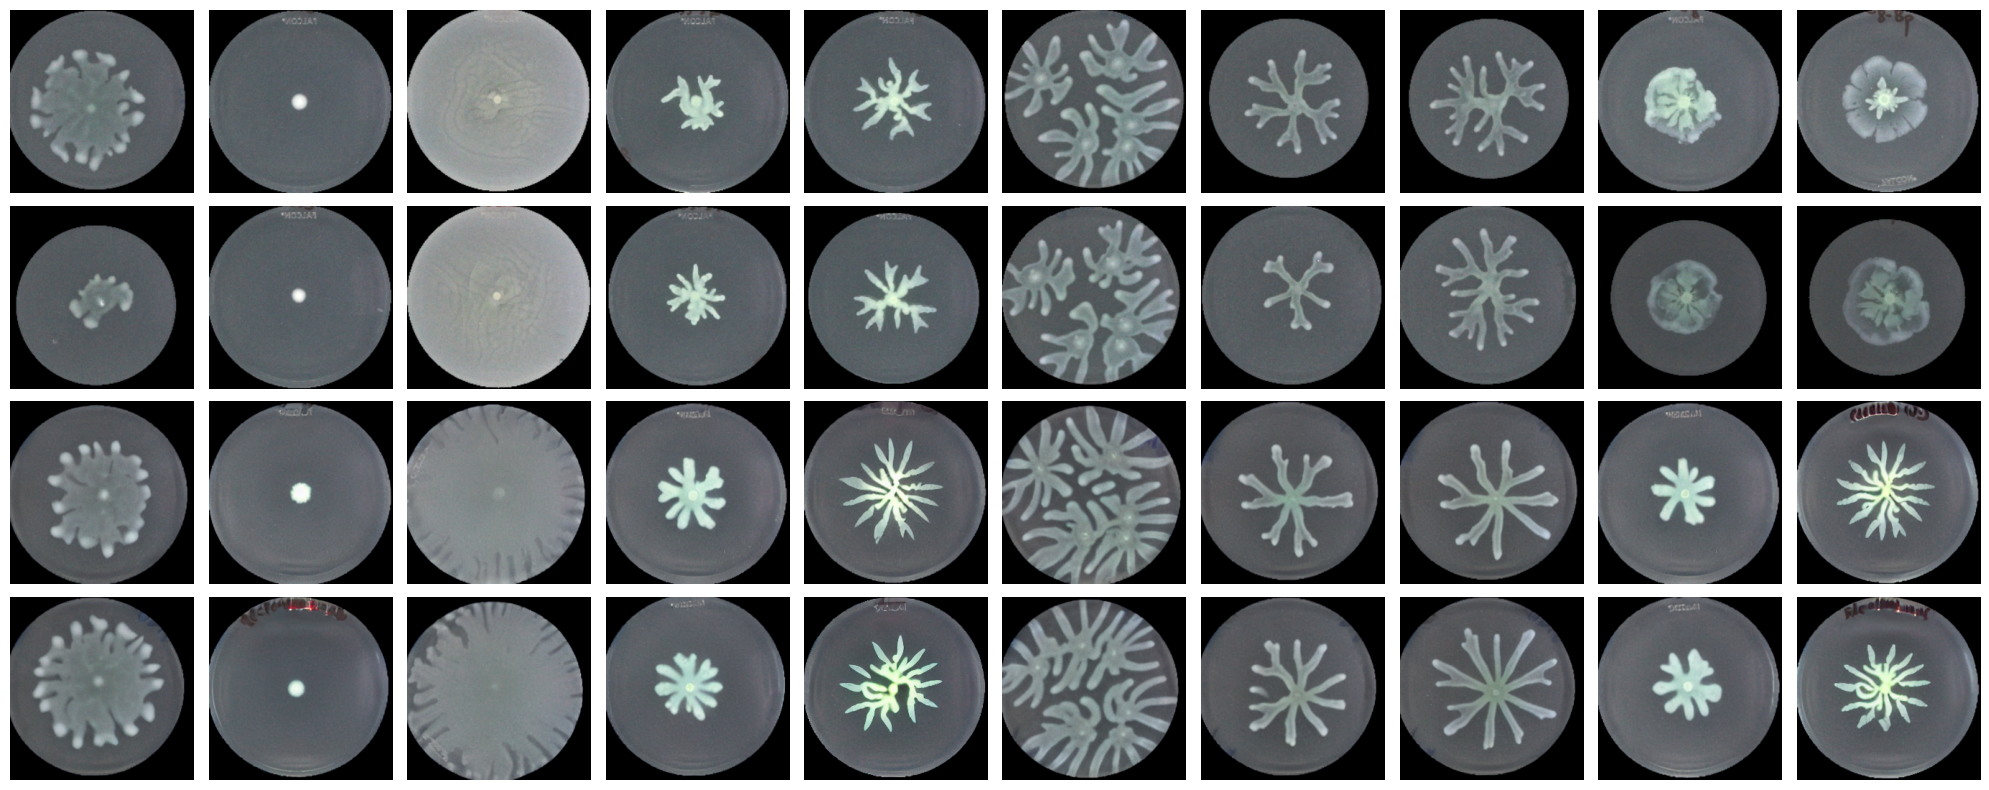

In [8]:
from local_config import  OUTPUT_DIR_REPTOREP_SAVED, EXP_FOLDER_TEST, EXP_FOLDER_TEST_V3, EMRAH_EXP_FOLDER_TEST
import os 
import cv2
import matplotlib.pyplot as plt
import shared_resources_config
from cldm.preprocess import preprocess_experimental_backgroundblack


# Plot ground truth vs predicted images 
# Row 1- Ground truth replicate 1 
# Row 2- Ground truth replicate 2
# Row 3- Generated image replicate 1
# Row 4- Generated image replicate 2

# Column 1- 6, good performance images
# Column 7-8, moderate cases 
# Column 9-10, poor performance images


# 86, 126, 127, 129, 138, 250, dphz1, dSoxR, 143, 144

Folder_ground_truth_PA= EXP_FOLDER_TEST
Folder_ground_truth_PA_mutantlib= EXP_FOLDER_TEST_V3
Folder_ground_truth_PA_Kp= EMRAH_EXP_FOLDER_TEST


Generated_images= OUTPUT_DIR_REPTOREP_SAVED

Selected_image_list= ['86', '126', '127', '129', '138', '250', 'dphz', 'dSoxR', '143', '144']

# Check for image_1.png or image_2.png in the generated images folder
# Check for image_1.TIF or image_2.TIF in the ground truth images folder
# For ground truth images, check files in all three folders

# Single figure: one column per image in Selected_image_list
fig, axs = plt.subplots(4, len(Selected_image_list), figsize=(2 * len(Selected_image_list), 8))

for col, image_name in enumerate(Selected_image_list):
    # Check in ground truth folders by first add the 1 or 2 suffix to the image

    gt_image_path_1 = os.path.join(Folder_ground_truth_PA, f"{image_name}_1.TIF")
    gt_image_path_2 = os.path.join(Folder_ground_truth_PA, f"{image_name}_2.TIF")
    gt_image_path_3 = os.path.join(Folder_ground_truth_PA_mutantlib, f"{image_name}_1.TIF")
    gt_image_path_4 = os.path.join(Folder_ground_truth_PA_mutantlib, f"{image_name}_2.TIF")
    gt_image_path_5 = os.path.join(Folder_ground_truth_PA_Kp, f"{image_name}_1.TIF")
    gt_image_path_6 = os.path.join(Folder_ground_truth_PA_Kp, f"{image_name}_2.TIF")
    

    # gt_image_path_2 = os.path.join(Folder_ground_truth_PA_mutantlib, f"{image_name}.TIF")
    # gt_image_path_3 = os.path.join(Folder_ground_truth_PA_Kp, f"{image_name}.TIF")

    # Check in the generated images folder
    gen_image_path_1 = os.path.join(Generated_images, f"{image_name}_1.png")
    gen_image_path_2 = os.path.join(Generated_images, f"{image_name}_2.png")

    # Load images if they exist
    gt_images = []
    for path in [gt_image_path_1, gt_image_path_2, gt_image_path_3, gt_image_path_4, gt_image_path_5, gt_image_path_6]:
        if os.path.exists(path):
            gt_images.append(preprocess_experimental_backgroundblack(path))
        else:
            print(f"Ground truth image not found: {path}")

    gen_images = []
    for path in [gen_image_path_1, gen_image_path_2]:
        if os.path.exists(path):
            gen_images.append(cv2.imread(path))
        else:
            print(f"Generated image not found: {path}")

    # Plotting: rows 0-1 are ground truth replicates 1-2, rows 2-3 are generated replicates 1-2
    for row in range(4):
        axs[row, col].axis('off')

   # gt images are already rgb, no need to convert to bgr

    if len(gt_images) > 0:
        axs[0, col].imshow(gt_images[0])
    # axs[0, col].set_title(image_name)

    if len(gt_images) > 1:
        axs[1, col].imshow(gt_images[1])

    if len(gen_images) > 0:
        axs[2, col].imshow(cv2.cvtColor(gen_images[0], cv2.COLOR_BGR2RGB))

    if len(gen_images) > 1:
        axs[3, col].imshow(cv2.cvtColor(gen_images[1], cv2.COLOR_BGR2RGB))

plt.tight_layout()
plt.show()
